# Proyecto 2 - Auditoria de datos y secuencias AML

**CC3092 - Deep Learning y Sistemas Inteligentes**  
Este notebook documenta la eleccion del conjunto de datos antes de modelar. La decision es parte evaluable del proyecto: no se debe entrenar un modelo de secuencias si los identificadores disponibles no tienen historial suficiente.

**Decision del proyecto:** se usara exclusivamente **PaySim**. Es un dataset sintetico, etiquetado y manejable en Google Colab; permite construir, entrenar y evaluar las dos etapas bajo un flujo reproducible.

## Criterios de diseno

- La unidad final deseada es una secuencia temporal por cliente/cuenta; los grupos de train, validacion y prueba no pueden compartir una cuenta.
- En PaySim, `nameOrig` no representa un remitente recurrente: la auditoria cuantifica esta limitacion. Por ello, la unidad de analisis del proyecto es una secuencia **centrada en cuenta**, incluyendo eventos donde una cuenta `C...` es origen o destino.
- Se usan `TRANSFER` y `CASH_OUT`, los dos tipos que contienen fraude etiquetado en PaySim. Esto reduce ruido y permite que el pipeline se ejecute en Colab en menos de 30 minutos. No implica que el sistema sea directamente aplicable a remesas reales.
- La etiqueta de una secuencia es positiva si al menos una de sus transacciones tiene `isFraud=1`. Es una etiqueta de investigacion, no una declaracion de culpabilidad de la cuenta.

In [2]:
# En Colab: suba el CSV o el ZIP a /content. En local, deje los archivos junto al notebook.
from pathlib import Path
from collections import Counter
import os, random, zipfile, sys
import numpy as np
import pandas as pd
import matplotlib
# Al ejecutar como script en Windows no se abre una ventana que bloquee el proceso.
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 3092
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

RUN_ROOT = Path('/content') if Path('/content').exists() else Path.cwd()
# En el repositorio, PaySim puede vivir en data/ o dos niveles arriba; en Colab se sube a /content.
DATA_ROOTS = [RUN_ROOT] if RUN_ROOT == Path('/content') else [RUN_ROOT / 'data', RUN_ROOT, RUN_ROOT.parent, RUN_ROOT.parent.parent]
ROOT, PAYSIM_CANDIDATES = RUN_ROOT, []
for candidate_root in DATA_ROOTS:
    candidates = list(candidate_root.glob('*log.csv'))
    if candidates:
        ROOT, PAYSIM_CANDIDATES = candidate_root, candidates
        break
print('Directorio de datos:', ROOT)
print('PaySim encontrados:', [p.name for p in PAYSIM_CANDIDATES])

Directorio de datos: c:\UVG\Semestre8\CC3092 - Deep Learning y Sistemas Inteligentes\Proyectos\Proyecto2
PaySim encontrados: ['PS_20174392719_1491204439457_log.csv']


In [4]:
# Si solo se subio el ZIP de PaySim, se extrae una vez.
if not PAYSIM_CANDIDATES:
    zips = list(ROOT.glob('*.zip'))
    if zips:
        with zipfile.ZipFile(zips[0]) as zf:
            zf.extractall(ROOT)
        PAYSIM_CANDIDATES = list(ROOT.glob('*log.csv'))

if not PAYSIM_CANDIDATES:
    raise FileNotFoundError('No se encontro el CSV de PaySim. Suba PS_*_log.csv o su ZIP a /content.')

PAYSIM_PATH = PAYSIM_CANDIDATES[0]
print(f'Usando: {PAYSIM_PATH.name} ({PAYSIM_PATH.stat().st_size / 1e6:.1f} MB)')

Usando: PS_20174392719_1491204439457_log.csv (493.5 MB)


In [5]:
# Auditoria completa en streaming: evita cargar 6.3M de filas solo para contar remitentes.
origin_counts, type_counts = Counter(), Counter()
n_rows = n_fraud = 0
for chunk in pd.read_csv(PAYSIM_PATH, usecols=['nameOrig', 'type', 'isFraud'], chunksize=250_000):
    n_rows += len(chunk)
    n_fraud += int(chunk['isFraud'].sum())
    origin_counts.update(chunk['nameOrig'])
    type_counts.update(chunk['type'])
origin_lengths = pd.Series(origin_counts, name='n_transacciones')
audit = pd.DataFrame([{
    'filas': n_rows, 'fraudes': n_fraud, 'tasa_fraude': n_fraud/n_rows,
    'remitentes_unicos': len(origin_lengths), 'remitentes_con_2_o_mas': int((origin_lengths >= 2).sum()),
    'remitentes_con_5_o_mas': int((origin_lengths >= 5).sum()), 'maximo_por_remitente': int(origin_lengths.max())
}])
display(audit.style.format({'tasa_fraude': '{:.4%}'}))
print('Transacciones por tipo:', dict(type_counts))
if origin_lengths.max() < 5:
    print('ADVERTENCIA METODOLOGICA: no hay historia suficiente por nameOrig; no se afirmara que son secuencias por remitente.')

,filas,fraudes,tasa_fraude,remitentes_unicos,remitentes_con_2_o_mas,remitentes_con_5_o_mas,maximo_por_remitente
0,6362620,8213,0.1291%,6353307,9298,0,3


Transacciones por tipo: {'PAYMENT': 2151495, 'TRANSFER': 532909, 'CASH_OUT': 2237500, 'DEBIT': 41432, 'CASH_IN': 1399284}
ADVERTENCIA METODOLOGICA: no hay historia suficiente por nameOrig; no se afirmara que son secuencias por remitente.


## Construccion de secuencias centradas en cuenta

Se cargan solamente las columnas necesarias y los tipos con fraude. Se seleccionan cuentas destino recurrentes y todas las cuentas que participan en una transaccion fraudulenta. Para cada cuenta candidata se conservan sus ultimos 32 eventos ordenados por `step`. Esta representacion conserva la direccion y el orden de las transacciones, y es la utilizada en todo el proyecto.

In [6]:
USECOLS = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
           'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
raw = pd.read_csv(PAYSIM_PATH, usecols=USECOLS)
raw = raw.loc[raw['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
raw['row_id'] = np.arange(len(raw), dtype=np.int64)

# Se evita usar cuentas de comerciantes M...: no son cuentas de cliente persistentes.
dest_counts = raw.loc[raw['nameDest'].str.startswith('C'), 'nameDest'].value_counts()
frequent_destinations = set(dest_counts[dest_counts >= 5].head(30_000).index)
fraud_rows = raw.loc[raw['isFraud'].eq(1)]
fraud_accounts = set(fraud_rows['nameOrig']) | set(fraud_rows['nameDest'])
candidate_accounts = frequent_destinations | fraud_accounts
print(f'Filas relevantes: {len(raw):,}; cuentas candidatas: {len(candidate_accounts):,}; cuentas asociadas a fraude: {len(fraud_accounts):,}')

Filas relevantes: 2,770,409; cuentas candidatas: 45,718; cuentas asociadas a fraude: 16,382


In [7]:
# Una transaccion aporta un evento saliente y/o entrante. direction evita perder ese contexto.
outgoing = raw.loc[raw['nameOrig'].isin(candidate_accounts)].copy()
outgoing['account_id'] = outgoing['nameOrig']; outgoing['direction'] = 1
incoming = raw.loc[raw['nameDest'].isin(candidate_accounts)].copy()
incoming['account_id'] = incoming['nameDest']; incoming['direction'] = 0
events = pd.concat([outgoing, incoming], ignore_index=True)
events = events.sort_values(['account_id', 'step', 'row_id', 'direction']).reset_index(drop=True)
lengths = events.groupby('account_id').size().rename('longitud')
account_labels = events.groupby('account_id')['isFraud'].max().rename('label')
eligible = lengths[lengths >= 2].index
events = events.loc[events['account_id'].isin(eligible)].copy()
sequence_table = pd.concat([lengths.loc[eligible], account_labels.loc[eligible]], axis=1)
display(sequence_table.groupby('label')['longitud'].describe().round(2))
print('Proporcion positiva por cuenta:', f"{sequence_table['label'].mean():.3%}")

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,29336.0,22.61,5.65,16.0,18.0,21.0,25.0,75.0
1,5085.0,8.48,7.26,2.0,3.0,6.0,12.0,56.0


Proporcion positiva por cuenta: 14.773%


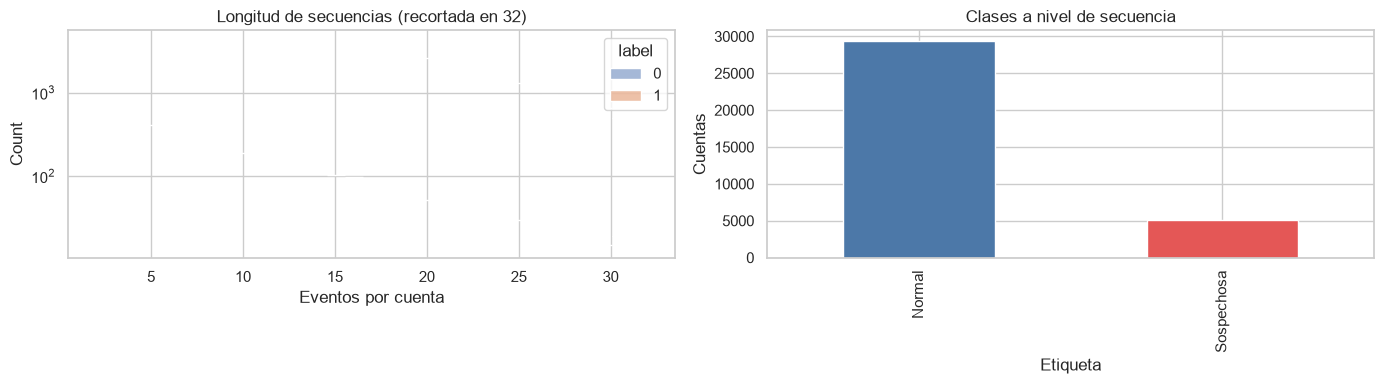

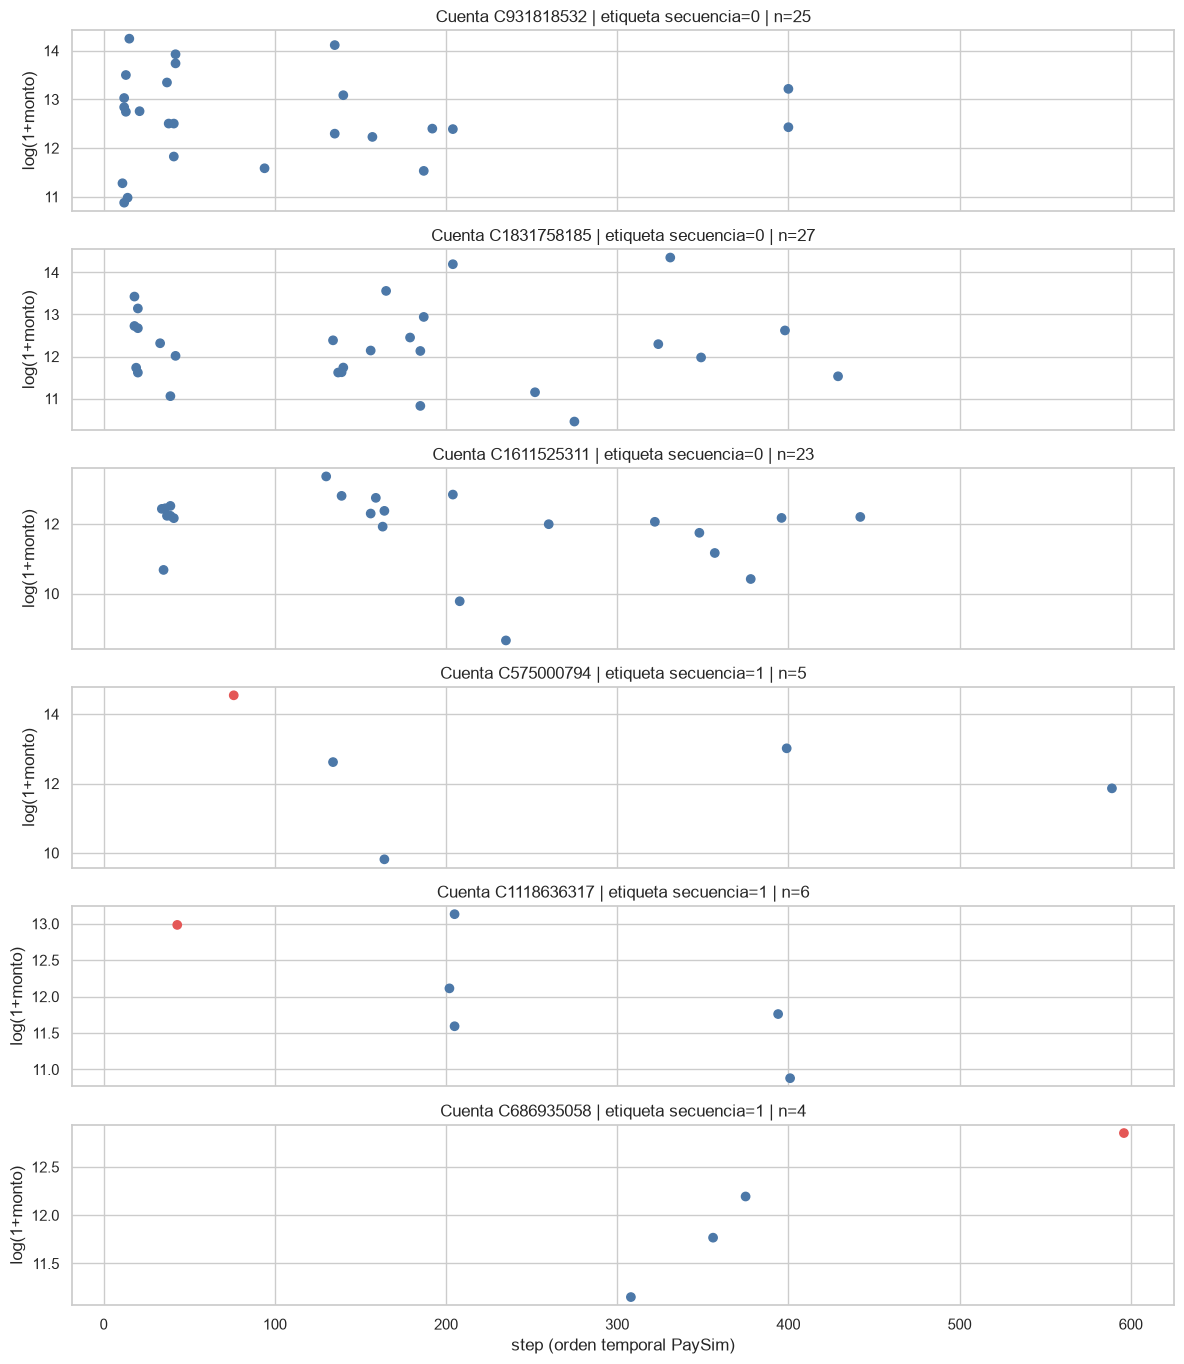

In [8]:
# Verificaciones exigidas antes de modelar: longitudes, clases y ejemplos visuales.
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=sequence_table.assign(longitud_clip=sequence_table['longitud'].clip(upper=32)),
             x='longitud_clip', hue='label', bins=31, multiple='layer', log_scale=(False, True), ax=ax[0])
ax[0].set(title='Longitud de secuencias (recortada en 32)', xlabel='Eventos por cuenta')
sequence_table['label'].value_counts().rename({0:'Normal', 1:'Sospechosa'}).plot.bar(ax=ax[1], color=['#4C78A8','#E45756'])
ax[1].set(title='Clases a nivel de secuencia', xlabel='Etiqueta', ylabel='Cuentas')
plt.tight_layout()

normal_ids = sequence_table.query('label == 0').sample(min(3, (sequence_table.label == 0).sum()), random_state=SEED).index
positive_ids = sequence_table.query('label == 1').sample(min(3, (sequence_table.label == 1).sum()), random_state=SEED).index
example_ids = list(normal_ids) + list(positive_ids)
fig, axes = plt.subplots(len(example_ids), 1, figsize=(12, max(5, 2.3*len(example_ids))), sharex=True)
for ax_i, account in zip(np.atleast_1d(axes), example_ids):
    e = events.loc[events.account_id.eq(account)].sort_values(['step','row_id']).tail(32)
    colors = e.isFraud.map({0:'#4C78A8', 1:'#E45756'})
    ax_i.scatter(e.step, np.log1p(e.amount), c=colors, s=36)
    ax_i.set_ylabel('log(1+monto)')
    ax_i.set_title(f'Cuenta {account} | etiqueta secuencia={int(e.isFraud.max())} | n={len(e)}')
axes[-1].set_xlabel('step (orden temporal PaySim)')
plt.tight_layout()

In [9]:
# Split por cuenta: una cuenta solo aparece en un split. Se balancea solo TRAIN, nunca validacion/prueba.
ids = sequence_table.index.to_numpy(); y = sequence_table['label'].astype(int).to_numpy()
train_ids, temp_ids, y_train, y_temp = train_test_split(ids, y, test_size=0.30, stratify=y, random_state=SEED)
val_ids, test_ids, y_val, y_test = train_test_split(temp_ids, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
assert not (set(train_ids) & set(val_ids) or set(train_ids) & set(test_ids) or set(val_ids) & set(test_ids))
splits = pd.DataFrame({'split':['train','validacion','prueba'], 'cuentas':[len(train_ids),len(val_ids),len(test_ids)],
                       'positivas':[y_train.mean(),y_val.mean(),y_test.mean()]})
display(splits.style.format({'positivas':'{:.3%}'}))

# La normalizacion se ajustara EXCLUSIVAMENTE con eventos de train.
FEATURES = ['log_amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','direction','is_transfer','delta_step']
events['log_amount'] = np.log1p(events['amount'])
events['is_transfer'] = events['type'].eq('TRANSFER').astype('float32')
events['delta_step'] = events.groupby('account_id')['step'].diff().fillna(0).clip(upper=48)
scaler = StandardScaler().fit(events.loc[events.account_id.isin(train_ids), FEATURES])
# Asignacion por columna: compatible con pandas reciente, que no permite truncar floats en columnas int.
scaled_features = scaler.transform(events[FEATURES]).astype('float32')
for position, feature in enumerate(FEATURES):
    events[feature] = scaled_features[:, position]
print('Features listas:', FEATURES)

,split,cuentas,positivas
0,train,24094,14.771%
1,validacion,5163,14.778%
2,prueba,5164,14.775%


Features listas: ['log_amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'direction', 'is_transfer', 'delta_step']


# Componente 2 - Sistema de deteccion en dos etapas

La **Etapa A** aprende exclusivamente la normalidad con un autoencoder GRU. Su error de reconstruccion es el score de anomalia. La **Etapa B** reutiliza el encoder de la Etapa A y aprende una clasificacion supervisada con una capa de atencion temporal.

La validacion decide todos los hiperparametros operativos (umbrales y peso de fusion). El conjunto de prueba se consulta una sola vez al final. La metrica principal es **PR-AUC**, pues el fraude es minoritario; se complementa con precision, recall y F1 en el umbral seleccionado.

In [10]:
# PyTorch viene preinstalado en Google Colab. Esta celda configura reproducibilidad y GPU.
import copy
import site
# Algunos entornos Windows necesitan registrar las DLL de torch antes de importarlo.
if os.name == 'nt':
    for base in [site.getusersitepackages(), *site.getsitepackages()]:
        torch_lib = Path(base) / 'torch' / 'lib'
        if torch_lib.exists():
            os.add_dll_directory(str(torch_lib))
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, precision_score, recall_score, f1_score

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| dispositivo:', DEVICE)

MAX_SEQ, HIDDEN, BATCH_SIZE = 32, 64, 256
AE_EPOCHS, HEAD_EPOCHS, FINETUNE_EPOCHS, BASELINE_EPOCHS = 8, 3, 8, 11
LR_AE, LR_HEAD, LR_FINETUNE = 1e-3, 1e-3, 3e-4

PyTorch: 2.14.0+cpu | dispositivo: cpu


In [11]:
# Convierte cada historial de cuenta en un tensor padded de longitud MAX_SEQ.
# Las secuencias se recortan por la izquierda: los eventos mas recientes se preservan.
def build_sequences(account_ids):
    account_ids = list(account_ids)
    x = np.zeros((len(account_ids), MAX_SEQ, len(FEATURES)), dtype=np.float32)
    mask = np.zeros((len(account_ids), MAX_SEQ), dtype=bool)
    labels = np.zeros(len(account_ids), dtype=np.float32)
    by_account = {account: frame for account, frame in events.groupby('account_id', sort=False)}
    for i, account in enumerate(account_ids):
        frame = by_account[account].sort_values(['step', 'row_id']).tail(MAX_SEQ)
        values = frame[FEATURES].to_numpy(dtype=np.float32)
        x[i, :len(values)] = values
        mask[i, :len(values)] = True
        labels[i] = float(sequence_table.loc[account, 'label'])
    return x, mask, labels, np.asarray(account_ids)

X_train, M_train, Y_train, ID_train = build_sequences(train_ids)
X_val, M_val, Y_val, ID_val = build_sequences(val_ids)
X_test, M_test, Y_test, ID_test = build_sequences(test_ids)
print('Tensores:', X_train.shape, X_val.shape, X_test.shape)
print('Normales para Etapa A:', int((Y_train == 0).sum()))

Tensores: (24094, 32, 8) (5163, 32, 8) (5164, 32, 8)
Normales para Etapa A: 20535


In [12]:
class SequenceDataset(Dataset):
    def __init__(self, x, mask, y):
        self.x = torch.from_numpy(x)
        self.mask = torch.from_numpy(mask)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.x[idx], self.mask[idx], self.y[idx]

def loader(x, mask, y, shuffle=False):
    # num_workers=0 evita fallos de spawn/DLL en Windows y mantiene compatibilidad con Colab.
    return DataLoader(SequenceDataset(x, mask, y), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

normal_train = Y_train == 0
ae_train_loader = loader(X_train[normal_train], M_train[normal_train], Y_train[normal_train], shuffle=True)
train_loader = loader(X_train, M_train, Y_train, shuffle=True)
val_loader = loader(X_val, M_val, Y_val)
test_loader = loader(X_test, M_test, Y_test)

In [13]:
class SequenceEncoder(nn.Module):
    def __init__(self, n_features, hidden=HIDDEN):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, batch_first=True)
    def forward(self, x, mask):
        lengths = mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, h = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        return out, h[-1]

class GRUAutoencoder(nn.Module):
    def __init__(self, n_features, hidden=HIDDEN):
        super().__init__()
        self.encoder = SequenceEncoder(n_features, hidden)
        self.decoder = nn.GRU(hidden, hidden, batch_first=True)
        self.output = nn.Linear(hidden, n_features)
    def forward(self, x, mask):
        _, z = self.encoder(x, mask)
        decoder_input = z.unsqueeze(1).expand(-1, x.size(1), -1)
        decoded, _ = self.decoder(decoder_input)
        return self.output(decoded)

class AttentionClassifier(nn.Module):
    def __init__(self, encoder, hidden=HIDDEN):
        super().__init__()
        self.encoder = encoder
        self.attention = nn.Linear(hidden, 1)
        self.head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(0.20), nn.Linear(hidden // 2, 1))
    def forward(self, x, mask):
        states, _ = self.encoder(x, mask)
        energy = self.attention(states).squeeze(-1).masked_fill(~mask, -1e9)
        weights = torch.softmax(energy, dim=1)
        context = torch.bmm(weights.unsqueeze(1), states).squeeze(1)
        return self.head(context).squeeze(-1), weights

def masked_reconstruction_loss(reconstruction, target, mask):
    per_step = (reconstruction - target).pow(2).mean(dim=-1)
    return (per_step * mask.float()).sum() / mask.float().sum()

def reconstruction_scores(model, data_loader):
    model.eval(); scores = []
    with torch.no_grad():
        for x, mask, _ in data_loader:
            x, mask = x.to(DEVICE), mask.to(DEVICE)
            per_step = (model(x, mask) - x).pow(2).mean(dim=-1)
            scores.append(((per_step * mask.float()).sum(dim=1) / mask.float().sum(dim=1)).cpu().numpy())
    return np.concatenate(scores)

AE epoch 01/8 | MSE normal train: 0.67906
AE epoch 02/8 | MSE normal train: 0.58592
AE epoch 03/8 | MSE normal train: 0.56205
AE epoch 04/8 | MSE normal train: 0.54579
AE epoch 05/8 | MSE normal train: 0.53402
AE epoch 06/8 | MSE normal train: 0.52581
AE epoch 07/8 | MSE normal train: 0.53058
AE epoch 08/8 | MSE normal train: 0.51783


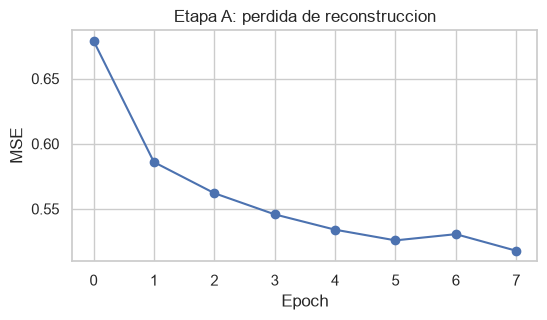

In [14]:
# ETAPA A: aprendizaje exclusivo de normalidad. No se pasan etiquetas positivas a este entrenamiento.
autoencoder = GRUAutoencoder(len(FEATURES)).to(DEVICE)
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=LR_AE, weight_decay=1e-5)
ae_history = []
for epoch in range(1, AE_EPOCHS + 1):
    autoencoder.train(); losses = []
    for x, mask, _ in ae_train_loader:
        x, mask = x.to(DEVICE), mask.to(DEVICE)
        optimizer_ae.zero_grad()
        loss = masked_reconstruction_loss(autoencoder(x, mask), x, mask)
        loss.backward(); torch.nn.utils.clip_grad_norm_(autoencoder.parameters(), 1.0); optimizer_ae.step()
        losses.append(loss.item())
    ae_history.append(np.mean(losses))
    print(f'AE epoch {epoch:02d}/{AE_EPOCHS} | MSE normal train: {ae_history[-1]:.5f}')

plt.figure(figsize=(6, 3)); plt.plot(ae_history, marker='o'); plt.title('Etapa A: perdida de reconstruccion'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.show()

normal_train_scores = reconstruction_scores(autoencoder, loader(X_train[normal_train], M_train[normal_train], Y_train[normal_train]))
val_anomaly = reconstruction_scores(autoencoder, val_loader)
test_anomaly = reconstruction_scores(autoencoder, test_loader)

,PR-AUC,ROC-AUC,Precision,Recall,F1
validacion,0.4555,0.7528,0.4895,0.4889,0.4892
prueba,0.4499,0.7379,0.4820,0.4744,0.4782


Umbral Etapa A seleccionado SOLO en validacion: 0.548836


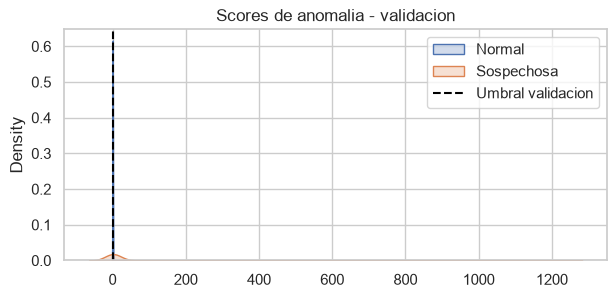

In [15]:
def best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    index = int(np.nanargmax(f1[:-1]))
    return float(thresholds[index]), float(precision[index]), float(recall[index]), float(f1[index])

def evaluate_scores(y_true, scores, threshold):
    predicted = (scores >= threshold).astype(int)
    return {'PR-AUC': average_precision_score(y_true, scores), 'ROC-AUC': roc_auc_score(y_true, scores),
            'Precision': precision_score(y_true, predicted, zero_division=0),
            'Recall': recall_score(y_true, predicted, zero_division=0),
            'F1': f1_score(y_true, predicted, zero_division=0)}

anomaly_threshold, _, _, _ = best_f1_threshold(Y_val, val_anomaly)
stage_a_val = evaluate_scores(Y_val, val_anomaly, anomaly_threshold)
stage_a_test = evaluate_scores(Y_test, test_anomaly, anomaly_threshold)
display(pd.DataFrame([stage_a_val, stage_a_test], index=['validacion', 'prueba']).round(4))
print(f'Umbral Etapa A seleccionado SOLO en validacion: {anomaly_threshold:.6f}')

plt.figure(figsize=(7, 3))
sns.kdeplot(x=val_anomaly[Y_val == 0], label='Normal', fill=True)
sns.kdeplot(x=val_anomaly[Y_val == 1], label='Sospechosa', fill=True)
plt.axvline(anomaly_threshold, color='black', linestyle='--', label='Umbral validacion')
plt.title('Scores de anomalia - validacion'); plt.legend(); plt.show()

In [16]:
def classifier_probabilities(model, data_loader, include_attention=False):
    model.eval(); probabilities, attentions = [], []
    with torch.no_grad():
        for x, mask, _ in data_loader:
            logits, attention = model(x.to(DEVICE), mask.to(DEVICE))
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
            if include_attention: attentions.append(attention.cpu().numpy())
    result = np.concatenate(probabilities)
    return (result, np.concatenate(attentions)) if include_attention else result

def fit_classifier(model, epochs, learning_rate, trainable_description):
    positives = float(Y_train.sum()); negatives = float(len(Y_train) - positives)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(negatives / positives, device=DEVICE))
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=learning_rate, weight_decay=1e-5)
    history = []
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for x, mask, y in train_loader:
            x, mask, y = x.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(); logits, _ = model(x, mask)
            loss = criterion(logits, y); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step(); losses.append(loss.item())
        history.append(np.mean(losses))
        print(f'{trainable_description} | epoch {epoch:02d}/{epochs} | BCE ponderada: {history[-1]:.4f}')
    return history

def tune_probability_threshold(y_true, probability):
    return best_f1_threshold(y_true, probability)[0]

In [17]:
# ETAPA B: transfer learning. Se copia el encoder para preservar intacto el modelo de anomalias.
transfer_model = AttentionClassifier(copy.deepcopy(autoencoder.encoder)).to(DEVICE)
for parameter in transfer_model.encoder.parameters(): parameter.requires_grad = False
head_history = fit_classifier(transfer_model, HEAD_EPOCHS, LR_HEAD, 'Transferencia: encoder congelado')
for parameter in transfer_model.encoder.parameters(): parameter.requires_grad = True
finetune_history = fit_classifier(transfer_model, FINETUNE_EPOCHS, LR_FINETUNE, 'Transferencia: fine-tuning')

transfer_val_prob = classifier_probabilities(transfer_model, val_loader)
transfer_test_prob, transfer_test_attention = classifier_probabilities(transfer_model, test_loader, include_attention=True)
transfer_threshold = tune_probability_threshold(Y_val, transfer_val_prob)
transfer_test_metrics = evaluate_scores(Y_test, transfer_test_prob, transfer_threshold)
print(f'Umbral clasificador transferido (validacion): {transfer_threshold:.4f}')
display(pd.DataFrame([transfer_test_metrics], index=['Transfer learning - prueba']).round(4))

Transferencia: encoder congelado | epoch 01/3 | BCE ponderada: 0.9137
Transferencia: encoder congelado | epoch 02/3 | BCE ponderada: 0.5726
Transferencia: encoder congelado | epoch 03/3 | BCE ponderada: 0.4819
Transferencia: fine-tuning | epoch 01/8 | BCE ponderada: 0.4222
Transferencia: fine-tuning | epoch 02/8 | BCE ponderada: 0.3740
Transferencia: fine-tuning | epoch 03/8 | BCE ponderada: 0.3493
Transferencia: fine-tuning | epoch 04/8 | BCE ponderada: 0.3306
Transferencia: fine-tuning | epoch 05/8 | BCE ponderada: 0.3202
Transferencia: fine-tuning | epoch 06/8 | BCE ponderada: 0.3113
Transferencia: fine-tuning | epoch 07/8 | BCE ponderada: 0.2951
Transferencia: fine-tuning | epoch 08/8 | BCE ponderada: 0.2922
Umbral clasificador transferido (validacion): 0.6240


,PR-AUC,ROC-AUC,Precision,Recall,F1
Transfer learning - prueba,0.9485,0.9604,0.9814,0.9004,0.9392


In [18]:
# Ablacion obligatoria: mismo clasificador, pero encoder aleatorio y sin Etapa A.
baseline_model = AttentionClassifier(SequenceEncoder(len(FEATURES))).to(DEVICE)
baseline_history = fit_classifier(baseline_model, BASELINE_EPOCHS, LR_HEAD, 'Baseline desde cero')
baseline_val_prob = classifier_probabilities(baseline_model, val_loader)
baseline_test_prob = classifier_probabilities(baseline_model, test_loader)
baseline_threshold = tune_probability_threshold(Y_val, baseline_val_prob)
baseline_test_metrics = evaluate_scores(Y_test, baseline_test_prob, baseline_threshold)
print(f'Umbral baseline (validacion): {baseline_threshold:.4f}')
display(pd.DataFrame([baseline_test_metrics], index=['Supervisado desde cero - prueba']).round(4))

Baseline desde cero | epoch 01/11 | BCE ponderada: 0.7403
Baseline desde cero | epoch 02/11 | BCE ponderada: 0.3472
Baseline desde cero | epoch 03/11 | BCE ponderada: 0.2982
Baseline desde cero | epoch 04/11 | BCE ponderada: 0.2818
Baseline desde cero | epoch 05/11 | BCE ponderada: 0.2716
Baseline desde cero | epoch 06/11 | BCE ponderada: 0.2659
Baseline desde cero | epoch 07/11 | BCE ponderada: 0.2601
Baseline desde cero | epoch 08/11 | BCE ponderada: 0.2557
Baseline desde cero | epoch 09/11 | BCE ponderada: 0.2499
Baseline desde cero | epoch 10/11 | BCE ponderada: 0.2488
Baseline desde cero | epoch 11/11 | BCE ponderada: 0.2419
Umbral baseline (validacion): 0.8646


,PR-AUC,ROC-AUC,Precision,Recall,F1
Supervisado desde cero - prueba,0.9604,0.9768,0.9914,0.9096,0.9487


In [19]:
# Fusion: la probabilidad supervisada y la anomalia normalizada se combinan.
# alpha y el umbral se eligen en validacion, nunca con prueba.
normal_mean, normal_std = normal_train_scores.mean(), normal_train_scores.std() + 1e-8
def anomaly_probability(scores): return 1 / (1 + np.exp(-np.clip((scores - normal_mean) / normal_std, -20, 20)))
val_anomaly_prob, test_anomaly_prob = anomaly_probability(val_anomaly), anomaly_probability(test_anomaly)
candidates = []
for alpha in np.linspace(0, 1, 21):
    score = alpha * transfer_val_prob + (1 - alpha) * val_anomaly_prob
    threshold, precision, recall, f1 = best_f1_threshold(Y_val, score)
    candidates.append((f1, alpha, threshold, precision, recall))
_, best_alpha, fusion_threshold, _, _ = max(candidates, key=lambda row: row[0])
fusion_test_prob = best_alpha * transfer_test_prob + (1 - best_alpha) * test_anomaly_prob
fusion_test_metrics = evaluate_scores(Y_test, fusion_test_prob, fusion_threshold)

ablation = pd.DataFrame([
    {'modelo':'Etapa A: solo anomalia', **stage_a_test},
    {'modelo':'Baseline supervisado desde cero', **baseline_test_metrics},
    {'modelo':'Etapa B: transfer learning', **transfer_test_metrics},
    {'modelo':f'Dos etapas fusionadas (alpha={best_alpha:.2f})', **fusion_test_metrics},
]).set_index('modelo')
display(ablation.round(4))
print(f'Fusion seleccionada en validacion: alpha={best_alpha:.2f}, umbral={fusion_threshold:.4f}')

,PR-AUC,ROC-AUC,Precision,Recall,F1
modelo,,,,,
Etapa A: solo anomalia,0.4499,0.7379,0.4820,0.4744,0.4782
Baseline supervisado desde cero,0.9604,0.9768,0.9914,0.9096,0.9487
Etapa B: transfer learning,0.9485,0.9604,0.9814,0.9004,0.9392
Dos etapas fusionadas (alpha=0.70),0.9497,0.9631,0.9800,0.9004,0.9385


Fusion seleccionada en validacion: alpha=0.70, umbral=0.5824


In [20]:
# Se guardan artefactos para C3/C4: scores y pesos de atencion por cuenta de prueba.
test_results = pd.DataFrame({
    'account_id': ID_test, 'label': Y_test.astype(int), 'anomaly_score': test_anomaly,
    'aml_probability': transfer_test_prob, 'final_score': fusion_test_prob,
    'prediction': (fusion_test_prob >= fusion_threshold).astype(int)
})
ARTIFACT_DIR = Path('artifacts'); ARTIFACT_DIR.mkdir(exist_ok=True)
test_results.to_csv(ARTIFACT_DIR / 'paysim_test_scores.csv', index=False)
torch.save({'autoencoder': autoencoder.state_dict(), 'classifier': transfer_model.state_dict(),
            'features': FEATURES, 'max_seq': MAX_SEQ, 'anomaly_threshold': anomaly_threshold,
            'fusion_threshold': fusion_threshold, 'fusion_alpha': best_alpha,
            'normal_mean': normal_mean, 'normal_std': normal_std}, ARTIFACT_DIR / 'paysim_two_stage_model.pt')
np.save(ARTIFACT_DIR / 'paysim_test_attention.npy', transfer_test_attention)
display(test_results.head())
print('Artefactos guardados en artifacts/: modelo, scores y atenciones.')

,account_id,label,anomaly_score,aml_probability,final_score,prediction
0,C1661320351,1,0.375968,0.243441,0.316679,0
1,C33637801,0,0.305459,0.096737,0.211964,0
2,C1270952292,0,0.420090,0.063753,0.192163,0
3,C766327981,0,0.408607,0.046790,0.179960,0
4,C1187610031,1,0.266431,0.999396,0.842707,1


Artefactos guardados: paysim_two_stage_model.pt, paysim_test_scores.csv, paysim_test_attention.npy
